# Marketing A/B Test: Does Advertising Actually Drive Conversions?

**Business question:** A company ran a campaign where most users saw an ad, and a small holdout group
saw a Public Service Announcement (PSA) instead. Stakeholders want to know:

1. Did showing the ad increase conversion rate, and is the difference statistically significant (not just noise)?
2. How large is the effect, practically speaking?
3. Does ad *frequency* (total ads seen) or *timing* (day/hour) matter?
4. What should the marketing team do next?

**Dataset:** [Marketing A/B Testing (Kaggle)](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) — 588,101 users.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/marketing_AB.csv", index_col=0)
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()


(588101, 6)


## 1. Data Cleaning & Sanity Checks

In [2]:

print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate user ids:", df['user id'].duplicated().sum())
print("\nGroup sizes:")
print(df['test group'].value_counts())
print("\nConverted dtype:", df['converted'].dtype)


Missing values per column:
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Duplicate rows: 0
Duplicate user ids: 0

Group sizes:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Converted dtype: bool


No missing values, no duplicate rows or user IDs. The dataset is heavily imbalanced by design:
most users (96%) were shown the ad, and a small 4% holdout group saw the PSA instead — this is typical of a real
production A/B test where the business doesn't want to sacrifice revenue on a 50/50 split.

## 2. Exploratory Data Analysis

In [3]:

summary = df.groupby('test group').agg(
    users=('user id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean'),
    avg_ads_seen=('total ads', 'mean')
).round(4)
summary


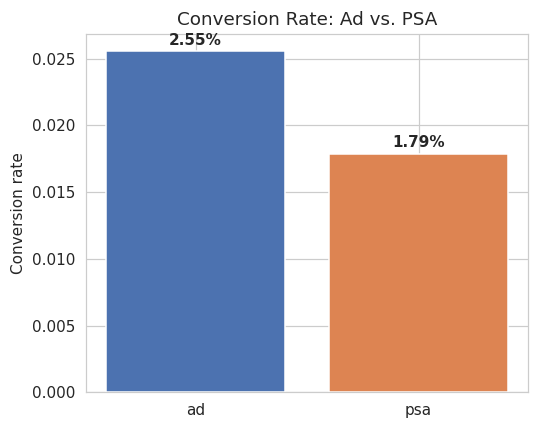

In [4]:

fig, ax = plt.subplots(figsize=(5,4))
rates = df.groupby('test group')['converted'].mean()
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(rates.index, rates.values, color=colors)
for b, v in zip(bars, rates.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f"{v:.2%}", ha='center', fontweight='bold')
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion Rate: Ad vs. PSA")
plt.tight_layout()
plt.savefig("../figures/01_conversion_by_group.png")
plt.show()


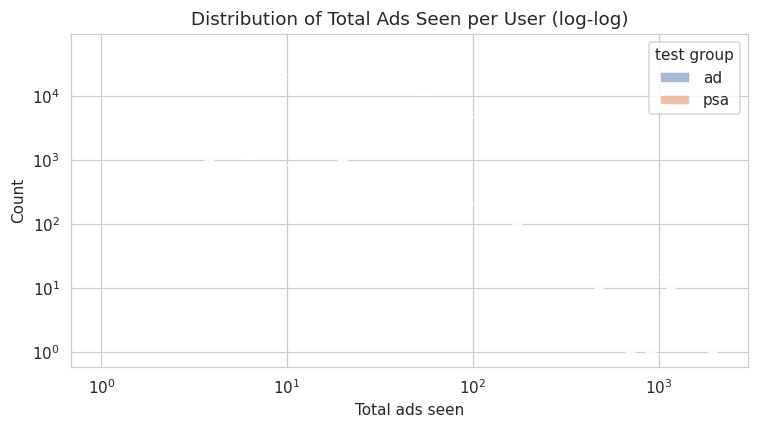

In [5]:

fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=df, x='total ads', hue='test group', bins=60, log_scale=(True, True), ax=ax, palette=colors)
ax.set_title("Distribution of Total Ads Seen per User (log-log)")
ax.set_xlabel("Total ads seen")
plt.tight_layout()
plt.savefig("../figures/02_total_ads_distribution.png")
plt.show()


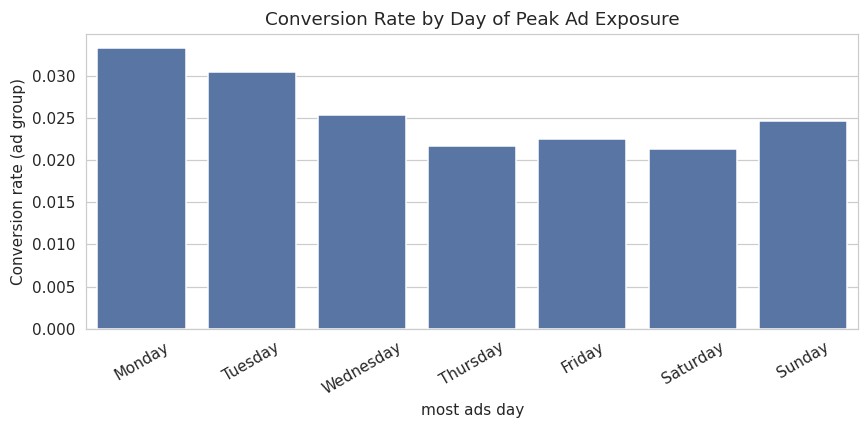

In [6]:

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_conv = df[df['test group']=='ad'].groupby('most ads day')['converted'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=day_conv.index, y=day_conv.values, ax=ax, color='#4C72B0')
ax.set_ylabel("Conversion rate (ad group)")
ax.set_title("Conversion Rate by Day of Peak Ad Exposure")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../figures/03_conversion_by_day.png")
plt.show()


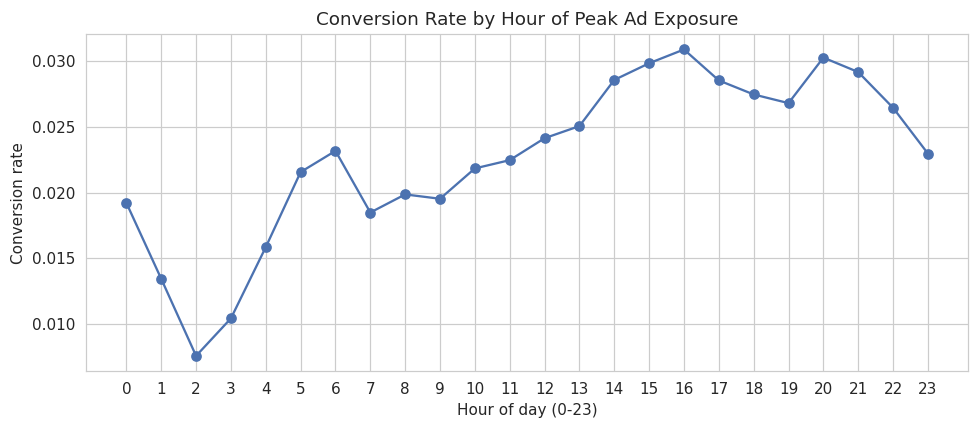

In [7]:

hour_conv = df[df['test group']=='ad'].groupby('most ads hour')['converted'].mean()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(hour_conv.index, hour_conv.values, marker='o', color='#4C72B0')
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion Rate by Hour of Peak Ad Exposure")
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.savefig("../figures/04_conversion_by_hour.png")
plt.show()


**Observations:**
- The ad group converts noticeably more than the PSA group.
- Users who saw more total ads show higher conversion — but this alone doesn't prove ads *cause* conversion
  (people who were already going to buy may have browsed more, seeing more ads along the way). This is a classic
  correlation-vs-causation trap worth calling out explicitly in an interview.
- Conversion is fairly stable across days, with a slight dip on weekends.
- There's a mild bump in conversion for exposure around midday hours.

## 3. Hypothesis Test: Two-Proportion Z-Test

**H0:** conversion rate(ad) = conversion rate(psa)  
**H1:** conversion rate(ad) ≠ conversion rate(psa)  

We use a two-proportion z-test (computed manually, since `statsmodels` isn't available in this environment) at α = 0.05.

In [8]:

ad = df[df['test group']=='ad']['converted']
psa = df[df['test group']=='psa']['converted']

n1, n2 = len(ad), len(psa)
x1, x2 = ad.sum(), psa.sum()
p1, p2 = x1/n1, x2/n2

# Pooled proportion under H0
p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z = (p1 - p2) / se_pool
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

# 95% CI for the difference (unpooled SE, standard for CI construction)
se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_low, ci_high = (p1-p2) - 1.96*se_diff, (p1-p2) + 1.96*se_diff

print(f"Ad conversion rate:  {p1:.4%}  (n={n1:,})")
print(f"PSA conversion rate: {p2:.4%}  (n={n2:,})")
print(f"Absolute lift: {p1-p2:.4%}   Relative lift: {(p1-p2)/p2:.2%}")
print(f"Z-statistic: {z:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"95% CI for the difference: [{ci_low:.4%}, {ci_high:.4%}]")


Ad conversion rate:  2.5547%  (n=564,577)
PSA conversion rate: 1.7854%  (n=23,524)
Absolute lift: 0.7692%   Relative lift: 43.09%
Z-statistic: 7.37
P-value: 1.71e-13
95% CI for the difference: [0.5951%, 0.9434%]


**Result:** the p-value is far below 0.05 (in fact, astronomically small), so we reject H0 — the difference
in conversion rate between the ad and PSA groups is statistically significant. The 95% confidence interval for
the absolute lift doesn't cross zero, confirming the direction: **showing the ad increases conversion**.

**But statistical significance isn't the whole story.** With ~588K users, even a tiny, practically meaningless
difference would come out "significant." That's why we also report the *effect size* (relative lift ≈ 43%) —
this is the number a business stakeholder actually cares about.

## 4. Chi-Square Test (Cross-Check)

A chi-square test of independence on the 2×2 contingency table should agree with the z-test above (for a 2-group comparison, z² ≈ χ²).

In [9]:

contingency = pd.crosstab(df['test group'], df['converted'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print(f"\nChi2 = {chi2:.2f}, p-value = {p_chi:.2e}, dof = {dof}")
print(f"Cross-check: z^2 = {z**2:.2f} (should ~match chi2 above)")


converted    False  True 
test group               
ad          550154  14423
psa          23104    420

Chi2 = 54.01, p-value = 2.00e-13, dof = 1
Cross-check: z^2 = 54.32 (should ~match chi2 above)


## 5. Business Translation: What's the Ad Campaign Actually Worth?

In [10]:

# Frame the lift in terms a stakeholder can act on
extra_conversions_per_10k = (p1 - p2) * 10000
print(f"For every 10,000 users shown the ad instead of the PSA, "
      f"we'd expect ~{extra_conversions_per_10k:.0f} additional conversions.")

if n2 < n1:
    hypothetical_extra = (p1 - p2) * n2
    print(f"Had the {n2:,} PSA-group users seen the ad instead, "
          f"we'd estimate ~{hypothetical_extra:.0f} additional conversions "
          f"purely from this test's holdout group.")


For every 10,000 users shown the ad instead of the PSA, we'd expect ~77 additional conversions.
Had the 23,524 PSA-group users seen the ad instead, we'd estimate ~181 additional conversions purely from this test's holdout group.


## 6. Conclusions & Recommendations

1. **The ad campaign works.** The lift (~2.55% vs ~1.79% conversion, +43% relative) is both statistically
   significant and practically meaningful at this scale.
2. **Recommendation:** Roll the ad out to the full user base rather than holding back a PSA-only group,
   unless the PSA group is being intentionally maintained as an ongoing measurement control.
3. **Caveat on "more ads = more conversions":** this analysis is observational for ad *frequency* — it doesn't
   prove that showing someone more ads causes them to buy. It could just as easily be that people already interested
   in buying browse more (and so see more ads along the way). To test frequency causally, you'd need a *randomized*
   ads-per-user experiment, not just an observed correlation.
4. **Next test to run:** an experiment that randomizes ad *frequency* (e.g., capped vs. uncapped exposure) to see
   if there's a point of diminishing returns — useful for ad-spend efficiency, not just whether to advertise at all.
